# Getting Started — Test Notebook

Runs every code example from the Getting Started documentation pages.
No observational data is needed: synthetic spectra are generated on the fly.

## Pre-flight — Cells from other documentation pages

Code blocks from documentation pages outside `getting_started/`.
Currently only `installation.rst` has a runnable Python snippet; the
API reference pages contain no executable examples.

### P1. Verify installation (from `installation.rst`)

In [1]:
import cometspec
print(cometspec.__version__)


0.1.1


### P2. `normalize_cn_systems_arg` examples (from `linelist.py` docstring)

In [2]:
from cometspec.linelist import normalize_cn_systems_arg

print(normalize_cn_systems_arg(None))
print(normalize_cn_systems_arg('both'))
print(normalize_cn_systems_arg('xx'))
print(normalize_cn_systems_arg('BX'))
print(normalize_cn_systems_arg(['bx', 'ax_dv1', 'bx']))  # dedup, order preserved
print(normalize_cn_systems_arg('unknown'))

['BX00', 'AX_dv1']
['BX00', 'AX_dv1', 'AX_dv2', 'AX_dv3']
['XX']
['BX00']
['BX00', 'AX_dv1']
['unknown']


/Users/baltasarluco/Desktop/CometSpec/.venv/lib/python3.11/site-packages/cometspec/linelist.py:169: UserWarning: normalize_cn_systems_arg: unrecognized system selector 'unknown', this will be omitted.
  warnings.warn(f"normalize_cn_systems_arg: unrecognized system selector {systems!r}, this will be omitted.")


---
## A. Fluorescence Model

### A0. Solar Irradiance at the comet

In [3]:
from cometspec.helper import open_kurucz_irradiance, open_hall_anderson_irradiance

irradiance_kurucz = open_kurucz_irradiance()
irradiance_hall_anderson = open_hall_anderson_irradiance()

import numpy as np
import pandas as pd

flux_kurucz = irradiance_kurucz['FLUX']
flux_hall_anderson = irradiance_hall_anderson['FLUX']

wave_kurucz = irradiance_kurucz['WAVE']
wave_hall_anderson = irradiance_hall_anderson['WAVE']

wave = np.concatenate([wave_hall_anderson, wave_kurucz])
flux = np.concatenate([flux_hall_anderson, flux_kurucz])

irradiance = pd.DataFrame({'WAVE': wave, 'FLUX': flux})

**Collisional parameter `f_col`** is defined as

$$f_{\rm col} \equiv \log_{10}(C_{ul}\,/\,\mathrm{s}^{-1}),$$

where the same downward rate $C_{ul}$ is assumed for every upper-to-lower pair included in the collision scaffold.

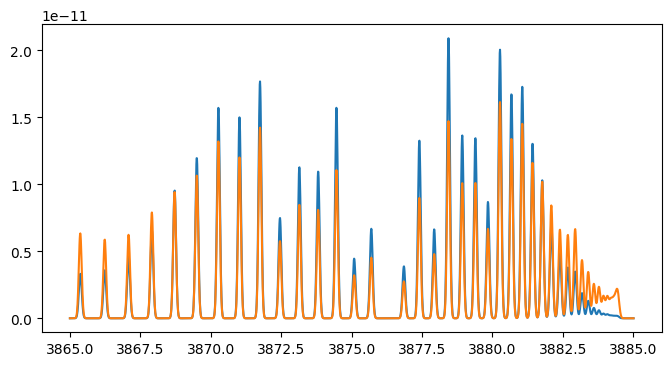

In [4]:
from cometspec import FluorescenceModel

import numpy as np
import pandas as pd
from astropy import constants as const


def blackbody_flux(wave_aa, T=5772.0):
    """
    Blackbody surface flux (pi*B_lambda) in erg/s/cm^2/AA.
    Matches Kurucz convention: emergent flux at the stellar surface.
    """
    wave_cm = wave_aa * 1e-8
    h = const.h.cgs.value
    c = const.c.cgs.value
    k_B = const.k_B.cgs.value

    exponent = h * c / (wave_cm * k_B * T)
    B_lambda = (2 * h * c**2 / wave_cm**5) / (np.exp(exponent) - 1.0)

    # pi*B_lambda gives surface flux; convert per-cm -> per-AA
    F_lambda = np.pi * B_lambda * 1e-8
    return F_lambda


def extend_with_blackbody(wave_shifted, flux_shifted, v_helio,
                          wave_max_rest=50_000.0, dwave=1.0,
                          T=5772.0, match_window=50.0):
    """
    Extend a Doppler-shifted, r^2-scaled Kurucz spectrum with a BB tail.

    Parameters
    ----------
    wave_shifted : array
        Wavelengths in the comet frame (already Doppler-shifted) [AA].
    flux_shifted : array
        Flux already divided by r^2 (comet-frame flux density).
    v_helio : float
        Heliocentric radial velocity of the comet [km/s],
        positive = receding from the Sun.
    wave_max_rest : float
        Upper wavelength limit in the SOLAR rest frame [AA].
    dwave : float
        Tail wavelength sampling in the rest frame [AA].
    T : float
        Blackbody temperature [K]. Default: solar T_eff = 5772 K.
    match_window : float
        Width of the anchor window for scale-matching [AA].
    """
    c_kms = 299792.458
    beta = v_helio / c_kms
    doppler = 1.0 + beta  # non-relativistic

    wave_shifted = np.asarray(wave_shifted)
    flux_shifted = np.asarray(flux_shifted)

    # Where does the existing grid end in the rest frame?
    wave_join_rest = wave_shifted.max() / doppler
    if wave_max_rest <= wave_join_rest:
        return wave_shifted, flux_shifted

    # Rest-frame wavelengths of the existing spectrum (for anchoring)
    wave_rest = wave_shifted / doppler

    # Scale BB to match the existing spectrum in the anchor window
    mask = wave_rest >= (wave_join_rest - match_window)
    flux_anchor = np.mean(flux_shifted[mask])
    bb_anchor = np.mean(blackbody_flux(wave_rest[mask], T=T))
    scale = flux_anchor / bb_anchor

    # Build BB tail on a rest-frame grid
    wave_tail_rest = np.arange(wave_join_rest + dwave,
                               wave_max_rest + dwave, dwave)
    flux_tail_rest = scale * blackbody_flux(wave_tail_rest, T=T)

    # Shift tail to comet frame:
    #   lambda_obs = lambda_rest * (1 + v/c)
    #   F_lambda transforms as 1/(1+z) -> divide flux density by doppler
    wave_tail_shifted = wave_tail_rest * doppler
    flux_tail_shifted = flux_tail_rest / doppler

    wave_ext = np.concatenate([wave_shifted, wave_tail_shifted])
    flux_ext = np.concatenate([flux_shifted, flux_tail_shifted])
    return wave_ext, flux_ext

wave_solar, flux_solar = extend_with_blackbody(
            irradiance['WAVE'], irradiance['FLUX'],
            v_helio=0,
            wave_max_rest=50_000.0
        )

solar = pd.DataFrame({'WAVE': wave_solar, 'FLUX': flux_solar})

model = FluorescenceModel(
   pumping=solar,
   isotopologues="12C14N",
   window = (3865, 3885),
   systems=['BX', 'AX_dv1', 'XX', 'AX_dv0', 'AX_dv2'],
   logN=14.0,        # log10 column density [moelcules cm^-2]
   T=300.0,          # Kinetic temperature [K]
   f_col=-2,           # log10 collision rate [s^-1]
   sigma=0.05,        # Gaussian LSF sigma [Å]
   A_min=0,         # Minimum einstein A for lines to include
   lsf_method="Gauss",
)
model2 = FluorescenceModel(
   pumping=solar,
   isotopologues="12C14N",
   window = (3865, 3885),
   systems=['BX', 'AX_dv1', 'XX'],
   logN=14.0,        # log10 column density [moelcules cm^-2]
   T=300.0,          # Kinetic temperature [K]
   f_col=-2,           # log10 collision rate [s^-1]
   sigma=0.05,        # Gaussian LSF sigma [Å]
   A_min=0,         # Minimum einstein A for lines to include
   lsf_method="Gauss",
)
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(model.model_wave, model.best_model, label='Model')
plt.plot(model2.model_wave, model2.best_model, label='Model')
plt.show()

### A1. One-isotopologue model

In [5]:
from cometspec import FluorescenceModel

model = FluorescenceModel(
   pumping=irradiance,
   isotopologues="12C14N",
   window = (3865, 3885),
   logN=14.0,        # log10 column density [moelcules cm^-2]
   T=100.0,          # Kinetic temperature [K]
   f_col=-1,           # log10 collision rate [s^-1]
   sigma=0.05,        # Gaussian LSF sigma [Å]
   A_min=1e3,         # Minimum einstein A for lines to include
   lsf_method="Gauss",
)

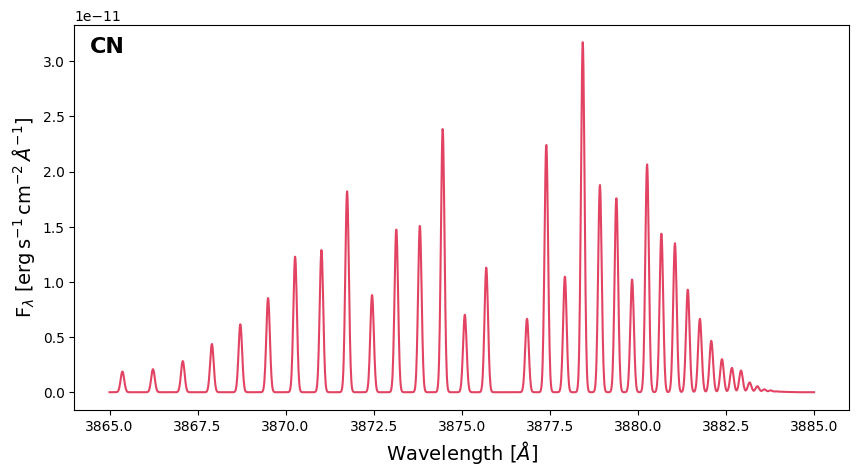

In [6]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 5))
plt.text(0.02, 0.97, "CN", transform=plt.gca().transAxes,
         fontsize=16, fontweight="bold", va="top")
plt.plot(model.model_wave, model.best_model, c='crimson', alpha=0.8)
plt.xlabel(r"Wavelength [$\AA$]", fontsize=14)
plt.ylabel(r"F$_\lambda$ [$\mathrm{erg}\,\mathrm{s}^{-1}\,\mathrm{cm}^{-2}\,\AA^{-1}$]", fontsize=14)
plt.show()

### A2. Two-isotopologue model

In [7]:
model2 = FluorescenceModel(
    pumping=irradiance,
    isotopologues=["12C14N", "Fe"],
    systems="BX",
    logN_by_iso={"12C14N": 13, "Fe": 12.5},
    T=300.0,
    f_col=-1,
    sigma=0.03,
    lsf_method="Gauss",
    include_rotations=True,
    A_min=1e4,
)


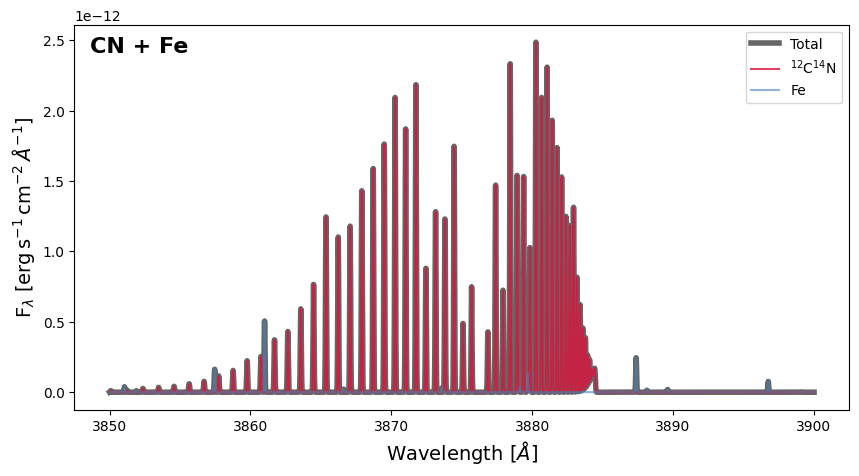

In [8]:

plt.figure(figsize=(10, 5))
plt.text(0.02, 0.97, "CN + Fe", transform=plt.gca().transAxes,
         fontsize=16, fontweight="bold", va="top")
plt.plot(model2.model_wave, model2.best_model, c='k', alpha=0.6, label="Total", lw=4)
plt.plot(model2.model_wave, model2.model_by_iso["12C14N"][1], c='crimson', label=r"$^{12}$C$^{14}$N", alpha=0.8)
plt.plot(model2.model_wave, model2.model_by_iso["Fe"][1], c='steelblue', label="Fe", alpha=0.6)
plt.xlabel(r"Wavelength [$\AA$]", fontsize=14)
plt.ylabel(r"F$_\lambda$ [$\mathrm{erg}\,\mathrm{s}^{-1}\,\mathrm{cm}^{-2}\,\AA^{-1}$]", fontsize=14)
plt.legend()
plt.show()

### A3. User-provided line list

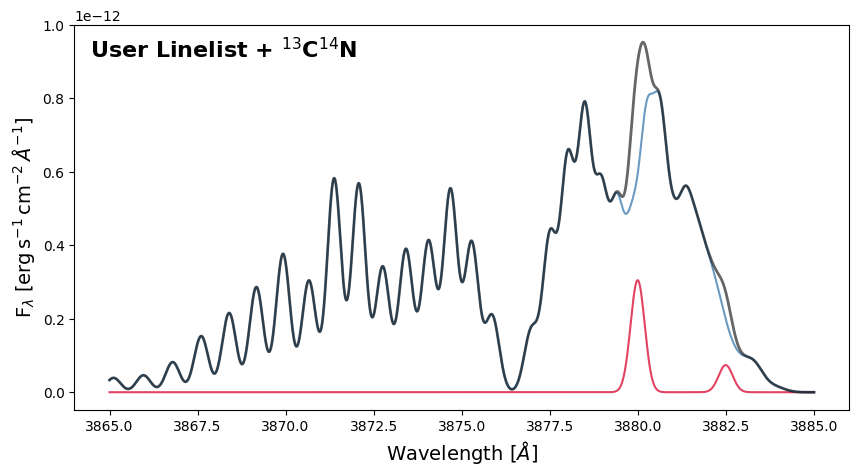

In [9]:
from cometspec.modeling import from_user_linelist

# Your data in whatever column names you have
raw_ll = pd.DataFrame({
    "wave": [3880.0, 3882.5],   # Angstroms
    "A":    [1e6,    5e5],       # Einstein A [s^-1]
    "uid":  ["u1",   "u2"],      # upper state label
    "lid":  ["l1",   "l2"],      # lower state label
    "gu":   [3,      5],         # upper degeneracy
    "gl":   [1,      3],         # lower degeneracy
})

# Convert to the normalized schema
user_ll = from_user_linelist(
    raw_ll,
    lam_col="wave", A_col="A",
    upper_id_col="uid", lower_id_col="lid",
    g_upper_col="gu", g_lower_col="gl",
)

model_user = FluorescenceModel(
    window=(3865, 3885),
    pumping=irradiance,
    isotopologues=["1Fx", "13C14N"],
    linelists={"1Fx": user_ll},
    logN_by_iso={"1Fx": 12.5, "13C14N": 13.0},
    T=100.0,
    sigma=0.2,
    lsf_method="Gauss",
    include_rotations=True, 
    A_min=1e4,
    f_col=-1,
)

plt.figure(figsize=(10, 5))
plt.text(0.02, 0.97, r"User Linelist + $^{13}$C$^{14}$N", transform=plt.gca().transAxes,
         fontsize=16, fontweight="bold", va="top")
plt.plot(model_user.model_by_iso["1Fx"][0], model_user.model_by_iso["1Fx"][1], c='crimson', alpha=0.8)
plt.plot(model_user.model_by_iso["13C14N"][0], model_user.model_by_iso["13C14N"][1], c='steelblue', alpha=0.8)
plt.plot(model_user.model_wave, model_user.best_model, c='k', alpha=0.6, label="Total", lw=2)
plt.xlabel(r"Wavelength [$\AA$]", fontsize=14)
plt.ylabel(r"F$_\lambda$ [$\mathrm{erg}\,\mathrm{s}^{-1}\,\mathrm{cm}^{-2}\,\AA^{-1}$]", fontsize=14)
plt.show()

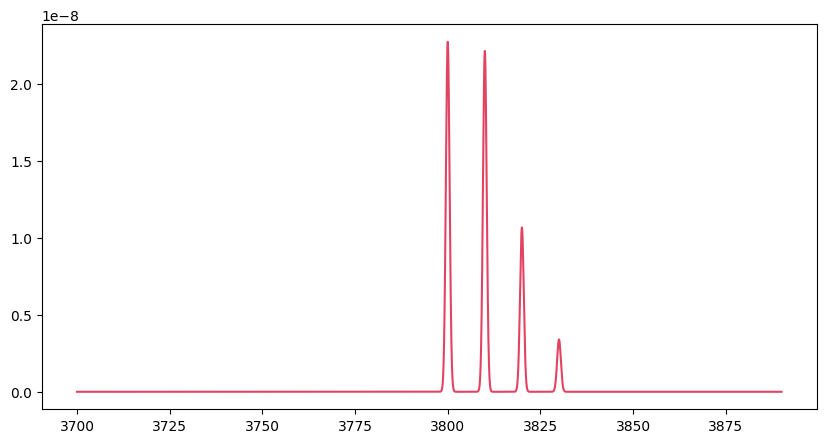

In [10]:
lines_wave = [3800, 3810, 3820, 3830, 3840]  # wavelengths in Angstroms
A = [1e4, 2e4, 3e4, 4e4, 5e4]  # Einstein A coefficients
upper_id_col = ['2', '3', '4', '5', '6']
lower_id_col = ['1', '2', '3', '4', '5']  # lower level IDs
g_upper_col = [1, 1, 1, 1, 1]  # statistical weights of the upper levels
g_lower_col = [2, 4, 6, 8, 10]  # statistical weights of the lower levels

loweres = ['X', 'X', 'X', 'X', 'X']  # electronic state
lowerv = [0, 0, 0, 0, 0]  # vibrational state
lowerJ = [0.5, 1.5, 2.5, 3.5, 4.5]  # J quantum numbers
lowersym = ['F1e', 'F1e', 'F1e', 'F1e', 'F1e']  # symmetry label
Elower = [1, 4, 9, 16, 25]  # energies with respect the ground state,cm^-1

custom_linelist_1 = pd.DataFrame({'WAVE': lines_wave,
                                'A_EINSTEIN': A,
                                'UPPER_ID': upper_id_col,
                                'LOWER_ID': lower_id_col,
                                'G_UPPER': g_upper_col,
                                'G_LOWER': g_lower_col,
                                'LOWER_ELECTRONIC_STATE': loweres,
                                'LOWER_VIBRATIONAL_STATE': lowerv,
                                'LOWER_J_LEVEL': lowerJ,
                                'LOWER_SYMMETRY': lowersym,
                                'E_LOWER': Elower
                                })

lines_custom = from_user_linelist(custom_linelist_1,
                                lam_col =  'WAVE',
                                A_col = 'A_EINSTEIN',
                                upper_id_col = 'UPPER_ID',
                                lower_id_col = 'LOWER_ID',
                                g_upper_col = 'G_UPPER',
                                g_lower_col = 'G_LOWER',
                                lower_es_col = 'LOWER_ELECTRONIC_STATE',
                                lower_v_col = 'LOWER_VIBRATIONAL_STATE',
                                lower_J_col = 'LOWER_J_LEVEL',
                                lower_sym_col = 'LOWER_SYMMETRY',
                                E_lower_cm1_col = 'E_LOWER',)

model_synth = FluorescenceModel(
            pumping=irradiance,
            isotopologues=['iso1'],
            window=(3700.0, 3890.0),
            linelists={'iso1': lines_custom},
            lsf=None,
            lsf_method="Gauss",
            sigma=0.5,
            A_min=1e3,
            logN_by_iso={'iso1': 12.0},
            f_col= 4,
            T=300.0,
            include_rotations=True
        )

plt.figure(figsize=(10, 5))
plt.plot(model_synth.model_wave, model_synth.best_model, c='crimson', alpha=0.8)
plt.show()

### A4. Updating the model

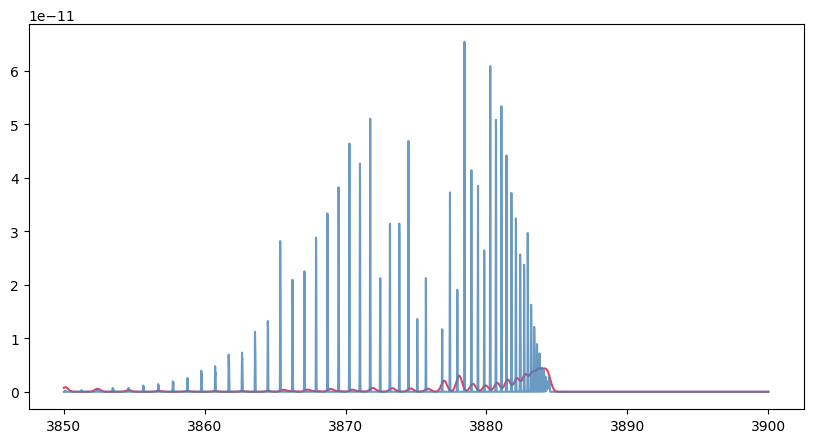

In [11]:
from cometspec import FluorescenceModel
from matplotlib import pyplot as plt
model = FluorescenceModel(pumping=irradiance,
    isotopologues="12C14N", systems="BX",
    logN=14.0, T=100.0, sigma=0.2, lsf_method="Gauss",
)
plt.figure(figsize=(10, 5))
plt.plot(model.model_wave, model.best_model, c='crimson', alpha=0.8)
model.sigma=0.01
model.T = 300

model.update_model(f_col=-1)
plt.plot(model.model_wave, model.best_model, c='steelblue', alpha=0.8)
plt.show()

### A5. Key output values

In [12]:
model = FluorescenceModel(pumping=irradiance,
               isotopologues=["12C14N", "13C14N"],
               logN_by_iso={"12C14N": 14.0, "13C14N": 13.0},
               T=100.0, sigma=0.2, lsf_method="Gauss", f_col=-1)

dic = model.n_lines()
print("-"*20)
print("Source of line lists:")
di2 = model.print_linelist_origins()
print("-"*20)
# Photon and energy g-factors
print("Photon g-factor [s^-1]:", model.g_ph_by_iso)
print("Energy g-factor [erg s^-1]:", model.g_en_by_iso)
print("-"*20)
print('Sum of photon g-factors:', model.g_ph_sum_by_iso)
print("-"*20)

print('Sum of energy g-factors:', model.g_en_sum_by_iso)
print("-"*20)

df_lines = model.lines_by_iso['12C14N']
print(df_lines)

print('Model parameters:')
print('-----------------')
print('LogN by isotopologue:')
for param, value in model.logN_by_iso.items():
   print(f'  {param}: {value}')
print('f_col:', model.f_col)
print('T:', model.T)
print('sigma:', model.sigma)
print('lsf_method:', model.lsf_method)

12C14N : 1037 lines
13C14N : 1146 lines
total  : 2183 lines
--------------------
Source of line lists:
12C14N : /Users/baltasarluco/Desktop/CometSpec/.venv/lib/python3.11/site-packages/cometspec/data/CN/12C14N.txt
13C14N : /Users/baltasarluco/Desktop/CometSpec/.venv/lib/python3.11/site-packages/cometspec/data/CN/13C14N.txt
--------------------
Photon g-factor [s^-1]: {'12C14N': array([2.36991166e-04, 3.55007583e-04, 4.34175621e-04, ...,
       1.04698779e-18, 4.20326007e-19, 4.16772904e-19], shape=(1037,)), '13C14N': array([1.74427473e-04, 3.30240874e-04, 4.18266838e-04, ...,
       1.00608320e-14, 5.04364344e-15, 6.00567355e-15], shape=(1146,))}
Energy g-factor [erg s^-1]: {'12C14N': array([5.11610911e-16, 7.66124287e-16, 9.36614977e-16, ...,
       5.48476947e-30, 2.20297649e-30, 2.18540337e-30], shape=(1037,)), '13C14N': array([3.75370270e-16, 7.10454050e-16, 8.99497177e-16, ...,
       5.22202101e-26, 2.61886177e-26, 3.11957391e-26], shape=(1146,))}
--------------------
Sum of phot

### A6. Using FluorescenceModelConfig

In [13]:
from cometspec import FluorescenceModelConfig

cfg = FluorescenceModelConfig(
    isotopologues=["12C14N", "13C14N"],
    systems="BX",
    logN=14.0,
    logN_by_iso={"13C14N": 12.9},
    T=100.0,
    sigma=0.2,
    lsf_method="Gauss",
)

# Build a model from the config
model_from_cfg = FluorescenceModel(
    model_wave=wave, pumping=irradiance, config=cfg
)

# Configs are plain dataclasses — easy to serialise
import json, dataclasses
print(json.dumps(dataclasses.asdict(cfg), indent=2, default=str))

{
  "data": "UNSET",
  "window": "UNSET",
  "pumping": "UNSET",
  "isotopologues": [
    "12C14N",
    "13C14N"
  ],
  "systems": "BX",
  "linelists": "UNSET",
  "line_path": "UNSET",
  "lsf": "UNSET",
  "lsf_method": "Gauss",
  "sigma": 0.2,
  "sigma1": "UNSET",
  "sigma2": "UNSET",
  "sigma_G": "UNSET",
  "fwhm_L": "UNSET",
  "ratio": "UNSET",
  "A_min": "UNSET",
  "a": "UNSET",
  "name": "UNSET",
  "logN": 14.0,
  "logN_by_iso": {
    "13C14N": 12.9
  },
  "f_col": "UNSET",
  "f_col_by_iso": "UNSET",
  "T": 100.0,
  "T_by_iso": "UNSET",
  "v_kms": "UNSET",
  "v_kms_by_iso": "UNSET",
  "dlam": "UNSET",
  "dlam_by_iso": "UNSET",
  "wave_col": "UNSET",
  "flux_col": "UNSET",
  "error_col": "UNSET",
  "continuum_col": "UNSET",
  "omega": "UNSET",
  "include_rotations": "UNSET",
  "pumping_v_kms": "UNSET",
  "pumping_dlam_A": "UNSET",
  "model_wave": "UNSET",
  "n_cores": "UNSET"
}


---
## B. MCMC Fitting

### B1. Single-isotopologue MCMC fit

In [14]:
from cometspec.helper import open_kurucz_irradiance, open_hall_anderson_irradiance
from cometspec import FluorescenceModel
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

irradiance = open_kurucz_irradiance()

In [15]:

model = FluorescenceModel(
    window=(3870, 3885),
    pumping=irradiance,
    isotopologues="12C14N",
    systems=['BX', 'AX_dv1'],
    sigma=0.05,
    f_col=-1,
    logN=14.0,
    T=200,
    v_kms=0,
    lsf_method="Gauss",
    wave_col="WAVE",
    flux_col="FLUX",
    error_col="ERR",
    continuum_col="CONTINUUM",
)

# add noise
data_flux = model.best_model + np.random.normal(0, np.max(model.best_model)*0.05, 
                                                    size=model.model_wave.shape)
data = pd.DataFrame({'WAVE': model.model_wave, 
                    'FLUX': data_flux, 
                    'ERR':np.max(model.best_model)*0.05, 
                    'CONTINUUM': np.zeros_like  (model.model_wave)})

results = model.fit_mcmc(
                data=data,
                nwalkers=10,
                nsteps=100,
                priors={
                    "logN":  (12.0, 16.0),
                    "T":     (50.0, 300.0),
                    "v_kms": (-2.0, 2.0),
                },
                    make_plots=False,
                )


Number of iterations: 3000


100%|██████████| 100/100 [00:18<00:00,  5.37it/s]


##################################################
*** Best fit (no pruning) ***
logN: 14.0023
T: 197.872
v_kms: -0.0660259
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.359
Mean acceptance fraction: 0.359
##################################################
*** Pruning... ***
3.3622589707374573 8.611127279859907 5.24886830912245
3.3622589707374573 7.763839245459308 4.401580274721851
3.2392099502831115 7.078049921037822 3.8388399707547105
3.2111022186800255 6.964912359781981 3.7538101411019555
3.1829944870769395 6.929045105779545 3.746050618702605
3.1181437313571223 6.785359091210683 3.667215359853561
3.092161473730812 6.4212313139587405 3.3290698402279286
3.081229786366748 6.133091451847836 3.0518616654810877
3.013503885038517 5.885924969583991 2.872421084545474
2.967496965167811 5.721343114527066 2.753846149359255
2.532119750376296 2.95175835890089 0.4196386085245938
2.0654810319974786 2.6028088540221517 0.5373278220246731
1.

Median logN : 14.002993716995839
Median T    : 198.7071758433155


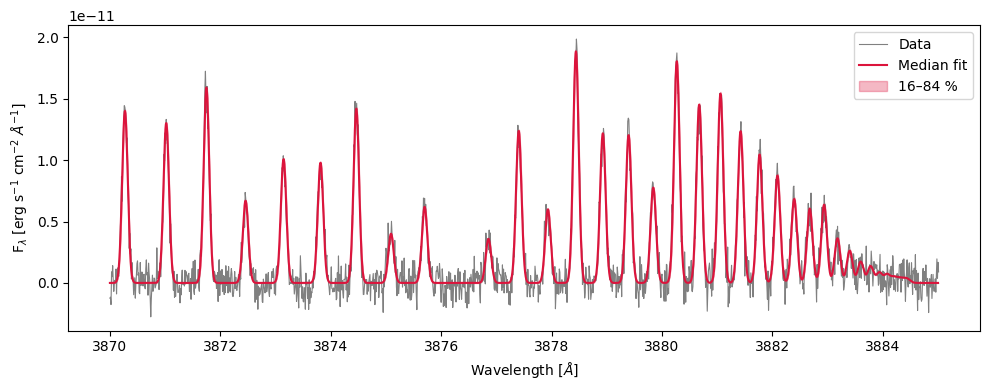

In [16]:

print("Median logN :", model.median_params["logN"])
print("Median T    :", model.median_params["T"])

plt.figure(figsize=(10, 4))
plt.plot(data["WAVE"], data["FLUX"], 
        color="gray", lw=0.8, label="Data")
plt.plot(model.model_wave, model.median_model,
        color="crimson", lw=1.5, label="Median fit")
plt.fill_between(
    model.model_wave,
    model.model_p16, model.model_p84,
    alpha=0.3, color="crimson", label="16–84 %",
)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"F$_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]")
plt.legend()
plt.tight_layout()
plt.savefig("Example_plots/mcmc_fit_example_test.png", dpi=300, format='png')
plt.show()

### B2. Multi-isotopologue MCMC fit

Number of iterations: 6000


100%|██████████| 100/100 [03:35<00:00,  2.15s/it]


##################################################
*** Best fit (no pruning) ***
logN_12C14N: 13.9983
logN_13C14N: 13.4984
T: 197.342
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.3795
Mean acceptance fraction: 0.3795
##################################################
*** Pruning... ***
2.066679706942523 3.6437620992750253 1.5770823923325024
2.0162913796521025 3.441048936021245 1.4247575563691424
1.9942294965003384 3.321316267648766 1.3270867711484278
1.9670224700166727 3.2402711458800053 1.2732486758633326
1.675061690104485 2.2875834249961846 0.6125217348916996
1.492513814177073 1.8430170570766764 0.35050324289960333
1.1309270282326906 1.296782012175942 0.16585498394325127
0.8817255783724249 0.9549118332873545 0.07318625491492958
logN_12C14N: 13.9995 +/- 0.0023  [13.9976, 14.0021]
logN_13C14N: 13.4994 +/- 0.0074  [13.4928, 13.5076]
T: 198.2492 +/- 1.6401  [196.4969, 199.7770]


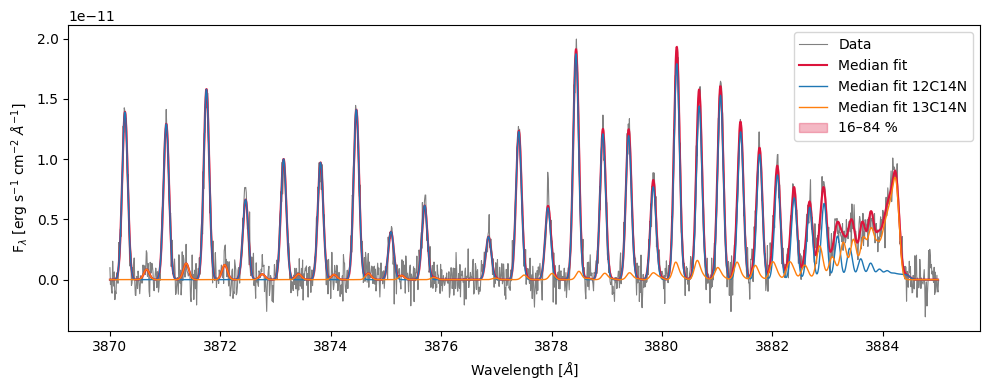

In [17]:
model2 = FluorescenceModel(
    window=(3870, 3885),
    pumping=irradiance,
    isotopologues=["12C14N", "13C14N"],
    systems=['BX', 'AX_dv1'],
    sigma=0.05,
    f_col_by_iso={"12C14N": -1, "13C14N": -2},
    logN_by_iso={"12C14N": 14.0, "13C14N": 13.5},
    T=200,
    v_kms=0,
    lsf_method="Gauss",
    wave_col="WAVE",
    flux_col="FLUX",
    error_col="ERR",
    continuum_col="CONTINUUM",
)

# add noise
data_flux = model2.best_model + np.random.normal(0, np.max(model2.best_model)*0.05,
                                                    size=model2.model_wave.shape)
data = pd.DataFrame({'WAVE': model2.model_wave,
                    'FLUX': data_flux,
                    'ERR':np.max(model2.best_model)*0.05,
                    'CONTINUUM': np.zeros_like  (model2.model_wave)})


results2 = model2.fit_mcmc(
    data=data,
nwalkers=20,
nsteps=100,
priors={
    "logN_12C14N": (12.0, 16.0),
    "logN_13C14N": (11.0, 15.0),
    "T":           (50.0, 300.0),
},
make_plots=False,
n_cores=2
)

plt.figure(figsize=(10, 4))
plt.plot(data["WAVE"], data["FLUX"],
        color="gray", lw=0.8, label="Data")
plt.plot(model2.model_wave, model2.median_model,
        color="crimson", lw=1.5, label="Median fit")
for iso in model2.isotopologues:
    plt.plot(model2.model_by_iso[iso][0], model2.model_by_iso[iso][1],
            lw=1.0, label=f"Median fit {iso}")
plt.fill_between(
    model2.model_wave,
    model2.model_p16, model2.model_p84,
    alpha=0.3, color="crimson", label="16–84 %",
)
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"F$_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]")
plt.legend()
plt.tight_layout()
plt.show()

### B3. Fixed parameters / LSF fitting

In [18]:
print('Original sigma:', model.sigma)

model.fit_mcmc(
    nwalkers=10, nsteps=100,
    priors={'logN': (12.0, 16.0), 'sigma': (0.01, 0.1)},
    make_plots=False,
)
print('Fitted sigma:', model.median_params.get('sigma'))
print('Fitted sigma:', model.sigma)

Original sigma: 0.05
Number of iterations: 2000


100%|██████████| 100/100 [00:21<00:00,  4.63it/s]


##################################################
*** Best fit (no pruning) ***
logN: 14.0026
sigma: 0.0498122
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.44299999999999995
Mean acceptance fraction: 0.44299999999999995
##################################################
*** Pruning... ***
0.8038039954371925 0.9126103320655284 0.10880633662833594
0.6226346902221849 0.6843981506381565 0.06176346041597158
logN: 14.0028 +/- 0.0020  [14.0003, 14.0042]
sigma: 0.0497 +/- 0.0004  [0.0494, 0.0502]
Fitted sigma: 0.04967009256815358
Fitted sigma: 0.04967009256815358


In [19]:
def lsf(x):
    """Example of a custom LSF function: a simple Gaussian."""
    import numpy as np  # imported inside so multiprocessing workers have access
    sigma = 0.02  # Standard deviation of the Gaussian
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x) / sigma) ** 2)

model = FluorescenceModel(pumping=irradiance,
                          isotopologues=['12C14N'],
                          systems=['B-X'],
                          lsf=lsf,
                          A_min=1e3,
                          logN = 14,
                          f_col= -1,
                          T=300.0,
                          window=(3865.0, 3885.0),
                          wave_col="WAVE",
                          flux_col="FLUX",
                          error_col="ERR",
                          continuum_col="CONTINUUM",
                          a=7)
#add noise
data_flux = model.best_model + np.random.normal(0, np.max(model.best_model)*0.05, size=model.model_wave.shape)
data = pd.DataFrame({'WAVE': model.model_wave, 'FLUX': data_flux, 'ERR':np.max(model.best_model)*0.05, 'CONTINUUM': np.zeros_like  (model.model_wave)}) 

model.fit_mcmc(
    data=data,
    nwalkers=20, nsteps=300,
    priors={'logN': (12.0, 16.0)},
    make_plots=False,
    lsf=model.lsf
)

Number of iterations: 6000


100%|██████████| 300/300 [00:31<00:00,  9.53it/s]


##################################################
*** Best fit (no pruning) ***
logN: 14.0054
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.48549999999999993
Mean acceptance fraction: 0.48549999999999993
##################################################
*** Pruning... ***
0.2351416841338505 0.44386728283376475 0.20872559869991425
0.23435000630706782 0.4392935388127786 0.2049435325057108
0.18881630119722104 0.3085613103990242 0.11974500920180314
0.1453338581486605 0.2289564514474104 0.08362259329874988
0.12266662926413119 0.17012230662707348 0.04745567736294229
0.08761863049585372 0.1254208582870991 0.03780222779124537
0.06750166125129908 0.09139855531495819 0.023896894063659108
0.04983281170279952 0.06753257915662313 0.01769976745382361
0.03749499551486224 0.05194125072744262 0.014446255212580382
0.02669834865446319 0.037125800437483814 0.010427451783020625
0.020058056237758137 0.027701875272283124 0.007643819034524987
0.01

{'param_keys': ['logN'],
 'median_params': {'logN': 14.005360746969721},
 'up_errors_params': {'logN': 8.562306400961006e-05},
 'low_errors_params': {'logN': 9.014320073141846e-05},
 'samples_pruned': array([[14.00530057],
        [14.00530057],
        [14.00530057],
        [14.00530072],
        [14.00523483],
        [14.00547264],
        [14.00547264],
        [14.00542625],
        [14.00531131],
        [14.00533542],
        [14.00546796],
        [14.00544586],
        [14.00523834],
        [14.00523834],
        [14.00524921],
        [14.00524921],
        [14.00543985],
        [14.00541471],
        [14.00541471],
        [14.00547997],
        [14.00541471],
        [14.00547997],
        [14.00526306],
        [14.00535049],
        [14.00542496],
        [14.00542496],
        [14.00544367],
        [14.00544367],
        [14.00544668],
        [14.00534719],
        [14.0053696 ],
        [14.00544668],
        [14.00534719],
        [14.00536075],
        [14.005382

### B4. Plotting posterior and fit vs data

Number of iterations: 60000


100%|██████████| 2000/2000 [01:28<00:00, 22.62it/s]


##################################################
*** Best fit (no pruning) ***
logN: 12.0096
f_col: -0.971977
T: 342.267
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.41955
Mean acceptance fraction: 0.41955
##################################################
*** Pruning... ***
1.0456968358921586 1.289863375523011 0.24416653963085233
1.0427890655919327 1.2859430187057697 0.24315395311383692
1.0394234629929997 1.2817082015956638 0.24228473860266408
1.0393093882521498 1.2782146185730867 0.2389052303209369
1.036434316290979 1.271633818261438 0.2351995019704589
1.0357312835913035 1.2692384995946095 0.23350721600330604
1.0352370750406408 1.2672052744432194 0.23196819940257862
0.8932169624094968 0.9830110028180482 0.08979404040855143
0.7175688901697868 0.7313407180428041 0.01377182787301734
logN: 12.0096 +/- 0.0045  [12.0054, 12.0143]
f_col: -0.8879 +/- 0.2145  [-1.0860, -0.6571]
T: 355.3051 +/- 31.6197  [320.5896, 383.8290]


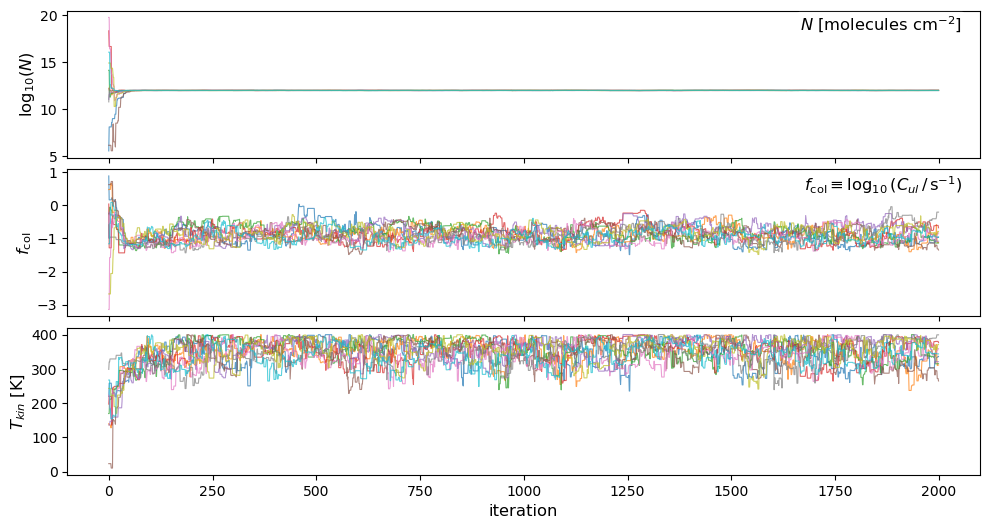

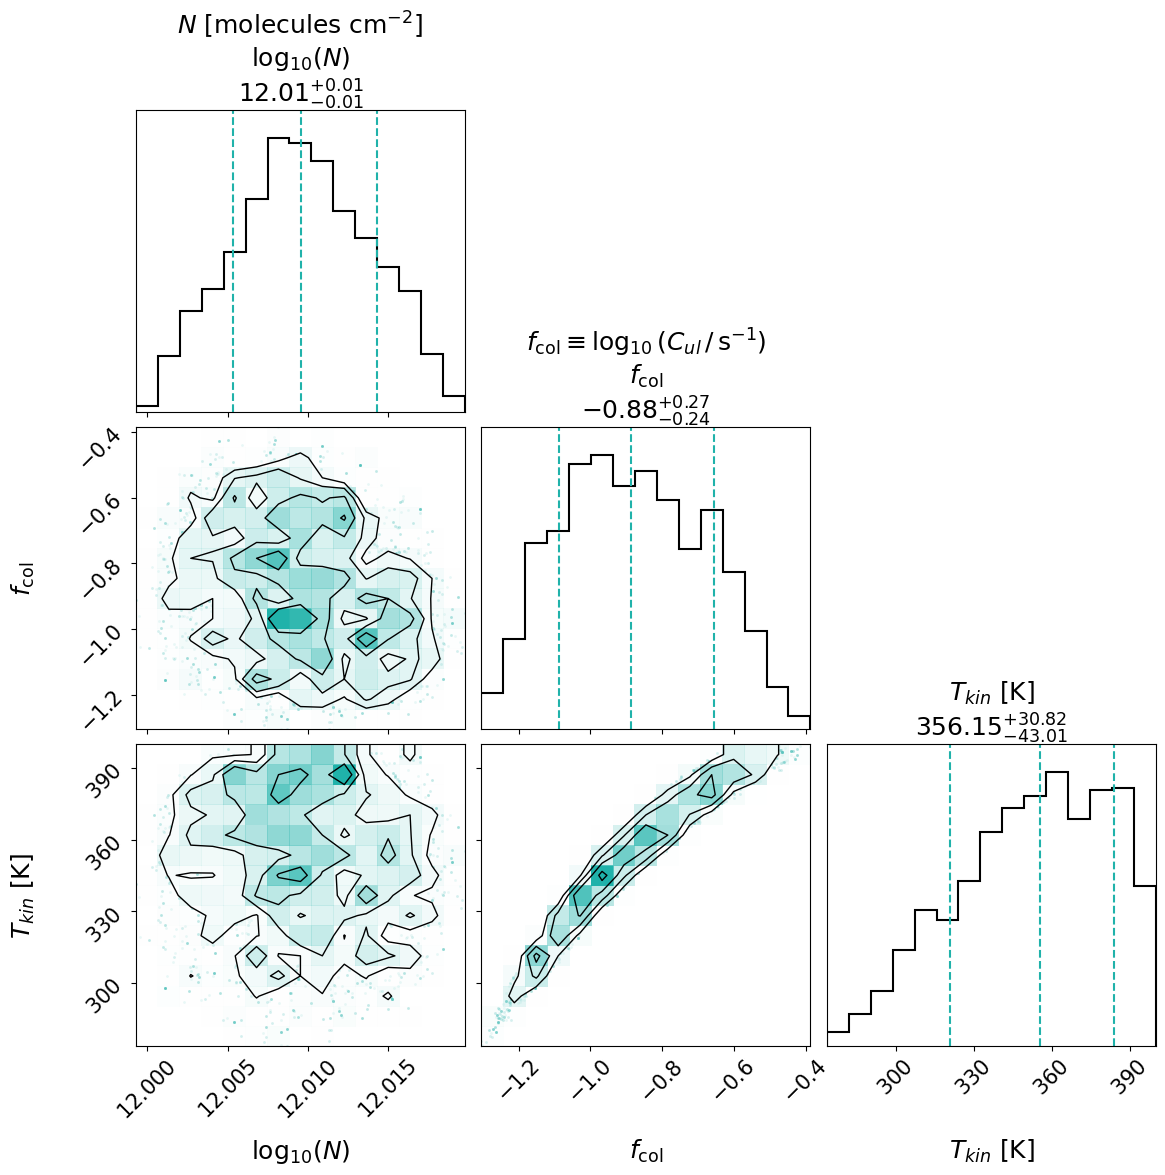

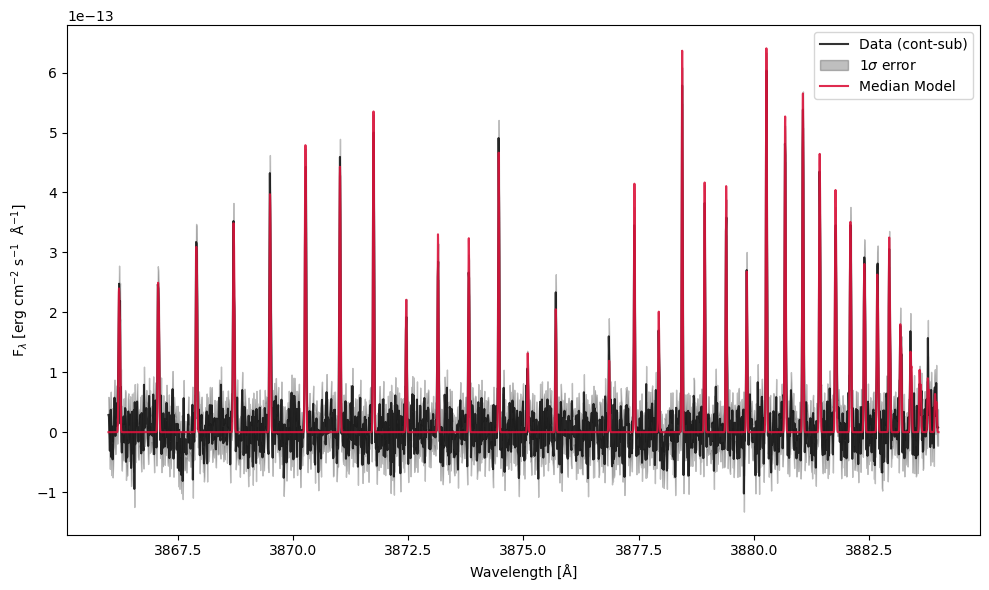

{'param_keys': ['logN', 'f_col', 'T'],
 'median_params': {'logN': 12.009576821242085,
  'f_col': -0.8878666895328574,
  'T': 355.3051177600069},
 'up_errors_params': {'logN': 0.004682957279440458,
  'f_col': 0.23078738796555875,
  'T': 28.523851443483522},
 'low_errors_params': {'logN': 0.004222167865581383,
  'f_col': 0.19817587511924917,
  'T': 34.71553239540674},
 'samples_pruned': array([[ 12.00724646,  -0.99845963, 343.27650806],
        [ 12.01239072,  -0.70180576, 385.35434894],
        [ 12.00557109,  -0.98704972, 339.88976378],
        ...,
        [ 12.01310801,  -0.8300887 , 358.76152011],
        [ 12.01548784,  -0.78721704, 370.66128042],
        [ 12.00589263,  -0.95604463, 343.45349332]], shape=(6564, 3)),
 'lnprob_pruned': array([53514.84329783, 53515.39981414, 53515.50969111, ...,
        53514.71070586, 53515.04986081, 53515.76937682], shape=(6564,)),
 'model_wave': array([3866.        , 3866.00090005, 3866.00180009, ..., 3883.99819991,
        3883.99909995, 3884.   

In [20]:
priors = {
    'logN': (5, 20),
    'f_col': (-4, 1),
    'T': (10, 400),
}

model = FluorescenceModel(
    window = (3866.0, 3884.0),
    pumping=irradiance,
    lsf_method="Gauss",
    A_min=1e4,
    name=f'CN_Model',
    sigma = 0.01,
    logN=12.0,
    v_kms=0.0,
    T=300.0,
    f_col=-1.0,
    isotopologues=['12C14N'],
    wave_col="WAVE",
    flux_col="FLUX",
    error_col="ERR",
    continuum_col="CONTINUUM",
)

# add noise
data_flux = model.best_model + np.random.normal(0, np.max(model.best_model)*0.05,
                                                size=model.model_wave.shape)
data = pd.DataFrame({'WAVE': model.model_wave, 'FLUX': data_flux,
                    'ERR':np.max(model.best_model)*0.05,
                    'CONTINUUM': np.zeros_like(model.model_wave)})

model.fit_mcmc(data = data,
           nwalkers=10,
           nsteps=2000,
           priors=priors,
           make_plots=True,
           progress=True,
           A_min=1e5,
           a=3,
           fig_file='Example_plots/example_test_getting_started',
           )

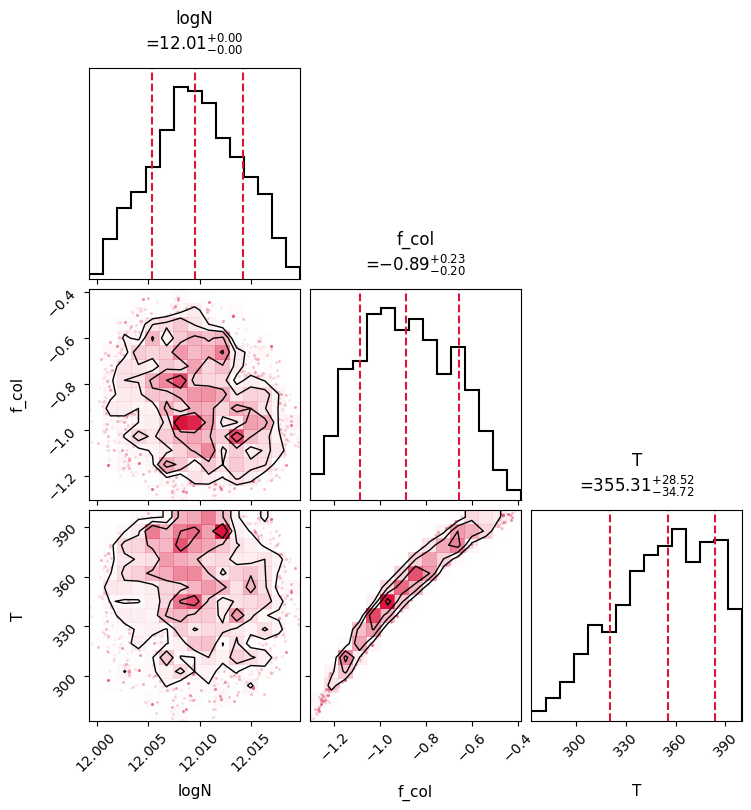

In [21]:
param_labels = model.param_keys
import corner
fig = corner.corner(
            model.samples_pruned,
            labels=param_labels,
            title_kwargs={'fontsize': 12, 'y': 1.05},
            title_fmt=".2f",
            use_math_text=True,
            bins=15,
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True,
            color='crimson',
            hist_kwargs={'color': 'black', 'linewidth': 1.5},
            contour_kwargs={'linewidths': 1, 'colors': 'black'},
            label_kwargs={'fontsize': 11},
            fig=plt.figure(figsize=(8, 8)), 
        )
axes = np.array(fig.axes).reshape((len(param_labels), len(param_labels)))

for i in range(len(param_labels)):
    ax = axes[i, i]
    q16, q50, q84 = np.quantile(model.samples_pruned[:, i], [0.16, 0.5, 0.84])
    q_minus, q_plus = q50 - q16, q84 - q50
    title = (
        f"{param_labels[i]}\n"
        rf"=${q50:.2f}_{{-{q_minus:.2f}}}^{{+{q_plus:.2f}}}$"
    )
    ax.set_title(title, fontsize=12, y=1.05)
plt.show()


### B5. Extracting results

In [22]:
print("Fitted parameters:", model.param_keys)
print("Medians          :", model.median_params)
print("Upper errors (1σ):", model.up_errors_params)
print("Lower errors (1σ):", model.low_errors_params)

# Formatted column density with asymmetric errors
logN_med = model.median_params["logN"]
logN_up  = model.up_errors_params["logN"]
logN_lo  = model.low_errors_params["logN"]
print(f"log N = {logN_med:.2f} +{logN_up:.2f} / -{logN_lo:.2f}  [cm^-2]")

# Full pruned sample chain (shape: n_samples × n_params)
print("Sample chain shape:", model.samples_pruned.shape)

Fitted parameters: ('logN', 'f_col', 'T')
Medians          : {'logN': 12.009576821242085, 'f_col': -0.8878666895328574, 'T': 355.3051177600069}
Upper errors (1σ): {'logN': 0.004682957279440458, 'f_col': 0.23078738796555875, 'T': 28.523851443483522}
Lower errors (1σ): {'logN': 0.004222167865581383, 'f_col': 0.19817587511924917, 'T': 34.71553239540674}
log N = 12.01 +0.00 / -0.00  [cm^-2]
Sample chain shape: (6564, 3)


### B6. Parallelization

In [23]:
results_par = model.fit_mcmc(
    nwalkers=20,
    nsteps=500,
    n_cores=2,                # parallelize walkers across 8 cores
    priors={
        "logN":  (12.0, 16.0),
        "T":     (50.0, 300.0),
        "v_kms": (-2.0, 2.0),
    },
    make_plots=False,
)

Number of iterations: 30000


100%|██████████| 500/500 [00:10<00:00, 45.64it/s]


##################################################
*** Best fit (no pruning) ***
logN: 12
T: 299.994
v_kms: -0.000481296
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.4015000000000001
Mean acceptance fraction: 0.4015000000000001
##################################################
*** Pruning... ***
2.1639611190912547 2.3879177277008523 0.22395660860959765
1.8006757050461601 1.829273493909465 0.028597788863304885
logN: 12.0004 +/- 0.0005  [12.0001, 12.0010]
T: 299.6902 +/- 0.2906  [299.3289, 299.9101]
v_kms: 0.0029 +/- 0.0100  [-0.0073, 0.0126]


### B7. Using MCMCFitConfig

In [24]:
from cometspec import MCMCFitConfig

mcmc_cfg = MCMCFitConfig(
    nwalkers=10,
    nsteps=100,
    n_cores=2,
    make_plots=False,
    priors={
        "logN":  (12.0, 16.0),
        "T":     (50.0, 300.0),
        "v_kms": (-2.0, 2.0),
    },
)

results_cfg = model2.fit_mcmc(config=mcmc_cfg)

Number of iterations: 3000


100%|██████████| 100/100 [00:34<00:00,  2.86it/s]


##################################################
*** Best fit (no pruning) ***
logN: 13.8046
T: 128.769
v_kms: 0.209772
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.40700000000000003
Mean acceptance fraction: 0.40700000000000003
##################################################
*** Pruning... ***
2.468650821057963 2.8712443416090894 0.4025935205511262
2.031223851889081 2.074997215382558 0.04377336349347738
logN: 13.8041 +/- 0.0029  [13.8014, 13.8071]
T: 129.1794 +/- 1.3328  [127.9699, 130.6354]
v_kms: 0.2236 +/- 0.0391  [0.1863, 0.2645]


### B8. Save and Load MCMC results

In [25]:
model.save(filename=f'MCMC_results/result_test_getting_started.pkl')

model = FluorescenceModel.load(filename=f'MCMC_results/result_test_getting_started.pkl')

---
## C. Production Rate

In [26]:
from cometspec.helper import open_kurucz_irradiance, open_hall_anderson_irradiance
from cometspec import FluorescenceModel
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

irradiance = open_kurucz_irradiance()

model = FluorescenceModel(
    window=(3870, 3885),
    pumping=irradiance,
    isotopologues="12C14N",
    systems=['BX', 'AX_dv1'],
    sigma=0.05,
    f_col=-1,
    logN=14.0,
    T=200,
    v_kms=0,
    lsf_method="Gauss",
    wave_col="WAVE",
    flux_col="FLUX",
    error_col="ERR",
    continuum_col="CONTINUUM",
)

# add noise
data_flux = model.best_model + np.random.normal(0, np.max(model.best_model)*0.05,
                                                    size=model.model_wave.shape)
data = pd.DataFrame({'WAVE': model.model_wave,
                    'FLUX': data_flux,
                    'ERR':np.max(model.best_model)*0.05,
                    'CONTINUUM': np.zeros_like(model.model_wave)})

results = model.fit_mcmc(
                data=data,
                nwalkers=10,
                nsteps=500,
                priors={
                    "logN":  (12.0, 16.0),
                    "T":     (50.0, 300.0),
                    "v_kms": (-2.0, 2.0),
                },
                    make_plots=False,
                )

Number of iterations: 15000


100%|██████████| 500/500 [01:48<00:00,  4.60it/s]


##################################################
*** Best fit (no pruning) ***
logN: 14.0037
T: 203.476
v_kms: 0.0368577
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.4622
Mean acceptance fraction: 0.4622
##################################################
*** Pruning... ***
1.0209048049728153 1.1345323085653334 0.11362750359251805
0.7990153424616437 0.8465874721486988 0.04757212968705504
logN: 14.0040 +/- 0.0023  [14.0015, 14.0062]
T: 203.6018 +/- 1.6733  [201.8608, 205.2073]
v_kms: 0.0366 +/- 0.0260  [0.0073, 0.0594]


### C1. Haser model — circular aperture

In [27]:
rh = 1.0   # your heliocentric distance [AU]

logQ, logQ_err = model.compute_production_rate(
    delta_au=1.0, #
    aperture={"type": "circular", "radius_arcsec": 5.0},
    parent_length_km=1.3e4 * rh**2,
    daughter_length_km=2.1e5 * rh**2,
    v_outflow_km_s=0.85 * rh**(-0.5),
)
print(f"log Q(CN) = {logQ:.2f} ± {logQ_err:.2f}  [s^-1]")

log Q(CN) = 28.41 ± 0.00  [s^-1]


### C2. Haser model — rectangular aperture

In [28]:
logQ_slit, logQ_slit_err = model.compute_production_rate(
    delta_au=1.0,
    aperture={"type": "rectangular", "width_arcsec": 2.0, "length_arcsec": 10.0},
    parent_length_km=1.3e4 * rh**2,
    daughter_length_km=2.1e5 * rh**2,
    v_outflow_km_s=0.85 * rh**(-0.5),
)
print(f"log Q(CN, slit) = {logQ_slit:.2f} ± {logQ_slit_err:.2f}")

log Q(CN, slit) = 28.36 ± 0.00


### C3. ρ⁻¹ profile via aperture integral

In [29]:
G = model.compute_aperture_integral(
    aperture={"type": "circular", "radius_arcsec": 5.0},
    delta_au=1.0,
)
print("Aperture integral G:", G)

logQ_prof, logQ_prof_err = model.compute_production_rate_from_profile(
    G=G,
    delta_au=1.0,
    aperture={"type": "circular", "radius_arcsec": 5.0},
    v_outflow_km_s=0.85 ,
)
print(f"log Q (rho^-1 profile) = {logQ_prof:.2f} ± {logQ_prof_err:.2f}")

Aperture integral G: 569626467.2277457 cm
log Q (rho^-1 profile) = 27.79 ± 0.00


### C4. Multi-isotopologue production rates

In [30]:
# Two-iso fit
model = FluorescenceModel(
    pumping=irradiance,
    isotopologues=["12C14N", "13C14N"], systems="BX",
    logN_by_iso={"12C14N": 14, "13C14N": 13.0},
    T=100.0, sigma=0.02, f_col=-1, lsf_method="Gauss",
    wave_col="WAVE", flux_col="FLUX", error_col="ERR",
    continuum_col="CONTINUUM",
)
data_flux = model.best_model + np.random.normal(0, np.max(model.best_model)*0.05,
                                                    size=model.model_wave.shape)
data = pd.DataFrame({'WAVE': model.model_wave,
                    'FLUX': data_flux,
                    'ERR':np.max(model.best_model)*0.05,
                    'CONTINUUM': np.zeros_like(model.model_wave)})


model.fit_mcmc(
    data=data,
    nwalkers=20, nsteps=300,
    priors={
        "logN_12C14N": (12.0, 16.0),
        "logN_13C14N": (11.0, 14.0),
        "T":           (50.0, 300.0),
    },
    make_plots=False, progress=False,
)

rates = model.compute_production_rate(
    delta_au=1.0,
    aperture={"type": "circular", "radius_arcsec": 5.0},
    parent_length_km=1.3e4 * rh**2,
    daughter_length_km=2.1e5 * rh**2,
    v_outflow_km_s=0.85 * rh**(-0.5),
)
for iso, (logQ_i, logQ_i_err) in rates.items():
    print(f"log Q({iso}) = {logQ_i:.2f} ± {logQ_i_err:.2f}")

Number of iterations: 18000
##################################################
*** Best fit (no pruning) ***
logN_12C14N: 14.0106
logN_13C14N: 13.0208
T: 103.98
##################################################
*** Acceptance Fraction ***
Mean acceptance fraction: 0.4588333333333333
Mean acceptance fraction: 0.4588333333333333
##################################################
*** Pruning... ***
logN_12C14N: 14.0114 +/- 0.0049  [14.0061, 14.0159]
logN_13C14N: 13.0078 +/- 0.0349  [12.9750, 13.0449]
T: 103.6951 +/- 1.6388  [101.9410, 105.2186]
log Q(12C14N) = 28.42 ± 0.00
log Q(13C14N) = 27.41 ± 0.03


### C5. Seeing-corrected production rate

In [31]:
print('Before adding slit-loss error:')
for iso in model.logQ:
    print(f"log Q({iso}) = {model.logQ[iso]:.3f} ± {model.logQ_err[iso]:.3f}")
for iso in model.logN_by_iso:
    print(f"log N({iso}) = {model.logN_by_iso[iso]:.2f} ± {model.logN_err_by_iso[iso][0]:.2f}") # for N you have up and low error, we just show 1

model.add_slit_loss_error(
   lambda_nm=388.3, # the wavelength of the fitted band or line [nm]
   aperture={"type": "circular", "radius_arcsec": .5}, # small aperture to illustrate the effect
   eps_min_arcsec_500=0.7,   # best-case seeing at 500 nm [arcsec]
   eps_max_arcsec_500=1.5,   # worst-case seeing at 500 nm [arcsec]
   zmin_deg=20, # minimum zenith angle of observations [degrees]
   zmax_deg=60, # maximum zenith angle of observations [degrees]
)

print('After adding slit-loss error:')
for iso in model.logQ:
    print(f"log Q({iso}) = {model.logQ[iso]:.3f} ± {model.logQ_err[iso]:.3f}")
for iso in model.logN_by_iso:
    print(f"log N({iso}) = {model.logN_by_iso[iso]:.2f} ± {model.logN_err_by_iso[iso][0]:.2f}") # for N you have up and low error, we just show 1


Before adding slit-loss error:
log Q(12C14N) = 28.418 ± 0.005
log Q(13C14N) = 27.415 ± 0.035
log N(12C14N) = 14.01 ± 0.00
log N(13C14N) = 13.01 ± 0.04
After adding slit-loss error:
log Q(12C14N) = 28.418 ± 0.392
log Q(13C14N) = 27.415 ± 0.394
log N(12C14N) = 14.01 ± 0.39
log N(13C14N) = 13.01 ± 0.39


---
## D. Utilities

### D1. Solar irradiance

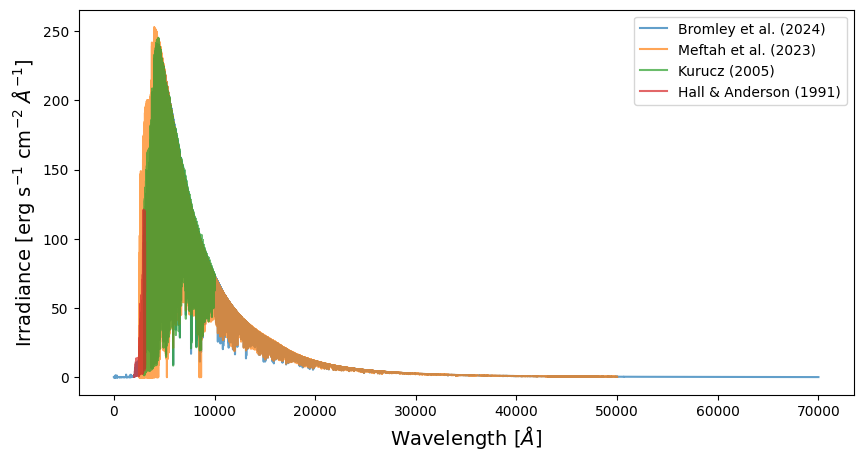

Kurucz 10009.998 2990.0009999999997
Hall & Anderson 3100.899720884942 2000.6481832193215
Meftah 49999.8250899 2499.9994275
Bromley 69998.916015625 1.0000000149011612


In [32]:
from cometspec.helper import open_kurucz_irradiance
from cometspec.helper import open_hall_anderson_irradiance
from cometspec.helper import open_meftah_irradiance
from cometspec.helper import open_bromley_irradiance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


irradiance_kurucz = open_kurucz_irradiance()
irradiance_hall_anderson = open_hall_anderson_irradiance(wave_max_AA=10000) # just a large wavelength to cover the max.
irradiance_meftah = open_meftah_irradiance()
irradiance_bromley = open_bromley_irradiance()

plt.figure(figsize=(10, 5))
plt.plot(irradiance_bromley['WAVE'], irradiance_bromley['FLUX'], label='Bromley et al. (2024)', alpha=0.7)
plt.plot(irradiance_meftah['WAVE'], irradiance_meftah['FLUX'], label='Meftah et al. (2023)', alpha=0.7)
plt.plot(irradiance_kurucz['WAVE'], irradiance_kurucz['FLUX'], label='Kurucz (2005)', alpha=0.7)
plt.plot(irradiance_hall_anderson['WAVE'], irradiance_hall_anderson['FLUX'], label='Hall & Anderson (1991)', alpha=0.7)
plt.xlabel(r"Wavelength [$\AA$]", fontsize=14)
plt.ylabel(r"Irradiance [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]", fontsize=14)
plt.legend()
plt.show()
print('Kurucz', max(irradiance_kurucz['WAVE']),min(irradiance_kurucz['WAVE']))
print('Hall & Anderson', max(irradiance_hall_anderson['WAVE']),min(irradiance_hall_anderson['WAVE']))
print('Meftah', max(irradiance_meftah['WAVE']),min(irradiance_meftah['WAVE']))
print('Bromley', max(irradiance_bromley['WAVE']),min(irradiance_bromley['WAVE']))


### D5. Slit-loss error on production rates

In [33]:
from cometspec.helper import add_slit_loss_error_scalar

logQ_err_nominal = 0.5   # initial uncertainty on log space

logQ_err_total = add_slit_loss_error_scalar(
    logQ_err_nominal,
    lambda_nm=388.3, # wavelength in which the slit-loss is calculated
    aperture={"type": "circular", "radius_arcsec": .5},
    eps_min_arcsec_500=0.7, # minimum seeing at 500 nm in arcseconds
    eps_max_arcsec_500=1.2, # maximum seeing at 500 nm in arcseconds
    zmin_deg=30.0, # minimum zenith angle in degrees
    zmax_deg=60.0, # maximum zenith angle in degrees
)

print(f"logQ error (MCMC only): {logQ_err_nominal:.3f}")
print(f"logQ error (total)    : {logQ_err_total:.3f}")

logQ error (MCMC only): 0.500
logQ error (total)    : 0.579


### D6. Converting a custom line list with from_user_linelist

In [34]:
import pandas as pd
from cometspec.modeling import from_user_linelist

raw = pd.DataFrame({
    "wave": [3883.0, 3884.5],
    "A":    [1e6,    5e5],
    "uid":  ["u1",   "u2"],
    "lid":  ["l1",   "l2"],
    "gu":   [3,      5],
    "gl":   [1,      3],
})

normalized = from_user_linelist(
    raw,
    lam_col="wave", A_col="A",
    upper_id_col="uid", lower_id_col="lid",
    g_upper_col="gu", g_lower_col="gl",
)
print(normalized)

   lambda_vac_A       A_ul upper_id lower_id  g_upper  g_lower         E_cm1
0        3883.0  1000000.0       u1       l1      3.0      1.0  25753.283544
1        3884.5   500000.0       u2       l2      5.0      3.0  25743.338911


### D7. Loading built-in line lists as DataFrames

In [35]:
from cometspec.modeling import load_default_transitions

# Load CN B-X for 12C14N and 13C14N
lls = load_default_transitions(
    isotopologues=["12C14N", "12C2"],
)
print(lls["12C14N"].head())
print(f"12C14N lines: {len(lls['12C14N'])}")

print(lls["12C2"].head())
print(f"12C2 lines: {len(lls['12C2'])}")


   lambda_vac_A      A_ul              upper_id              lower_id  \
0   9201.721661  13389.02  A|v=1|J=2.5|sym=F1_e  X|v=0|J=3.5|sym=F1_e   
1   9204.816435  16324.94  A|v=1|J=3.5|sym=F1_e  X|v=0|J=4.5|sym=F1_e   
2   9208.334102  18537.92  A|v=1|J=4.5|sym=F1_e  X|v=0|J=5.5|sym=F1_e   
3   9212.271896  20331.21  A|v=1|J=5.5|sym=F1_e  X|v=0|J=6.5|sym=F1_e   
4   9216.626898  21844.39  A|v=1|J=6.5|sym=F1_e  X|v=0|J=7.5|sym=F1_e   

   g_upper  g_lower       E_cm1 lower_es  lower_v  lower_J lower_sym  \
0      6.0      8.0  10867.5315        X      0.0      3.5      F1_e   
1      8.0     10.0  10863.8777        X      0.0      4.5      F1_e   
2     10.0     12.0  10859.7276        X      0.0      5.5      F1_e   
3     12.0     14.0  10855.0856        X      0.0      6.5      F1_e   
4     14.0     16.0  10849.9564        X      0.0      7.5      F1_e   

   E_lower_cm1  
0      22.7030  
1      37.8337  
2      56.7451  
3      79.4362  
4     105.9063  
12C14N lines: 1037
   lamb

In [36]:
print('Everything is working fine!')

Everything is working fine!
